# **Waste Material Segregation for Improving Waste Management**

## **Objective**

The objective of this project is to implement an effective waste material segregation system using convolutional neural networks (CNNs) that categorises waste into distinct groups. This process enhances recycling efficiency, minimises environmental pollution, and promotes sustainable waste management practices.

The key goals are:

* Accurately classify waste materials into categories like cardboard, glass, paper, and plastic.
* Improve waste segregation efficiency to support recycling and reduce landfill waste.
* Understand the properties of different waste materials to optimise sorting methods for sustainability.

## **Data Understanding**

The Dataset consists of images of some common waste materials.

1. Food Waste
2. Metal
3. Paper
4. Plastic
5. Other
6. Cardboard
7. Glass


**Data Description**

* The dataset consists of multiple folders, each representing a specific class, such as `Cardboard`, `Food_Waste`, and `Metal`.
* Within each folder, there are images of objects that belong to that category.
* However, these items are not further subcategorised. <br> For instance, the `Food_Waste` folder may contain images of items like coffee grounds, teabags, and fruit peels, without explicitly stating that they are actually coffee grounds or teabags.

## **1. Load the data**

Load and unzip the dataset zip file.

**Import Necessary Libraries**

In [1]:
# Recommended versions:

# numpy version: 1.26.4
# pandas version: 2.2.2
# seaborn version: 0.13.2
# matplotlib version: 3.10.0
# PIL version: 11.1.0
# tensorflow version: 2.18.0
# keras version: 3.8.0
# sklearn version: 1.6.1

In [2]:
# Import essential libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from PIL import Image  
import tensorflow as tf  
from tensorflow import keras

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report


import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="seaborn._statistics")


Load the dataset.

In [3]:
# Load and unzip the dataset

import os
import zipfile
from pathlib import Path

# Define dataset zip path and extraction path
zip_path = Path("C:/Users/deepa/OneDrive/Desktop/cnn_assignment/Dataset_Waste_Segregation.zip")
extract_path = Path("C:/Users/deepa/OneDrive/Desktop/cnn_assignment/Unzipped_Waste_Segregation")

def unzip_dataset_waste_segregation(zip_path, extract_path):
    if not zip_path.exists():
        raise FileNotFoundError(f"Zip file not found at {zip_path}")

    if extract_path.exists():
        print(f" Dataset already extracted at {extract_path}")
    else:
        print(f" Extracting dataset from {zip_path} to {extract_path}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print("Extraction complete.")

    return extract_path

dataset_path_waste_segregation = unzip_dataset_waste_segregation(zip_path, extract_path)

 Dataset already extracted at C:\Users\deepa\OneDrive\Desktop\cnn_assignment\Unzipped_Waste_Segregation


## **2. Data Preparation** <font color=red> [25 marks] </font><br>


### **2.1 Load and Preprocess Images** <font color=red> [8 marks] </font><br>

Let us create a function to load the images first. We can then directly use this function while loading images of the different categories to load and crop them in a single step.

#### **2.1.1** <font color=red> [3 marks] </font><br>
Create a function to load the images.

In [4]:
# Create a function to load the raw images
def load_images_original_size(data_dir, verbose=False):
    data_dir = Path(data_dir)
    class_names = sorted([f.name for f in data_dir.iterdir() if f.is_dir()])
    class_to_idx = {cls_name: idx for idx, cls_name in enumerate(class_names)}
    
    images = []
    labels = []
    
    for cls_name in class_names:
        folder = data_dir / cls_name
        img_paths = list(folder.glob("*.jpg")) + list(folder.glob("*.png")) + list(folder.glob("*.jpeg"))
        
        if verbose:
            print(f"Loading class '{cls_name}' with {len(img_paths)} images.")
        
        for img_path in img_paths:
            try:
                img = Image.open(img_path).convert('RGB')  # Keep original size, RGB mode
                images.append(img)
                labels.append(class_to_idx[cls_name])
            except Exception as e:
                if verbose:
                    print(f"Error loading {img_path.name}: {e}")
    
    if verbose:
        print(f"Total images loaded: {len(images)}")
    
    return images, labels, class_names

#### **2.1.2** <font color=red> [5 marks] </font><br>
Load images and labels.

Load the images from the dataset directory. Labels of images are present in the subdirectories.

Verify if the images and labels are loaded correctly.

In [5]:
# Get the images and their labels

dataset_path_waste_segregation = Path('C:/Users/deepa/OneDrive/Desktop/cnn_assignment/Unzipped_Waste_Segregation/data')

images, labels, class_names = load_images_original_size(dataset_path_waste_segregation, verbose=True)

print("\n Dataset Loaded:")
print(f"Total images : {len(images)}")
print(f"Example image size (width x height): {images[0].size}")
print(f"Total labels: {len(labels)}")
print(f"Class labels: {class_names}")


Loading class 'Cardboard' with 540 images.
Loading class 'Food_Waste' with 1000 images.
Loading class 'Glass' with 750 images.
Loading class 'Metal' with 1000 images.
Loading class 'Other' with 1010 images.
Loading class 'Paper' with 1030 images.
Loading class 'Plastic' with 2295 images.
Total images loaded: 7625

 Dataset Loaded:
Total images : 7625
Example image size (width x height): (256, 256)
Total labels: 7625
Class labels: ['Cardboard', 'Food_Waste', 'Glass', 'Metal', 'Other', 'Paper', 'Plastic']


Perform any operations, if needed, on the images and labels to get them into the desired format.

### **2.2 Data Visualisation** <font color=red> [9 marks] </font><br>

#### **2.2.1** <font color=red> [3 marks] </font><br>
Create a bar plot to display the class distribution

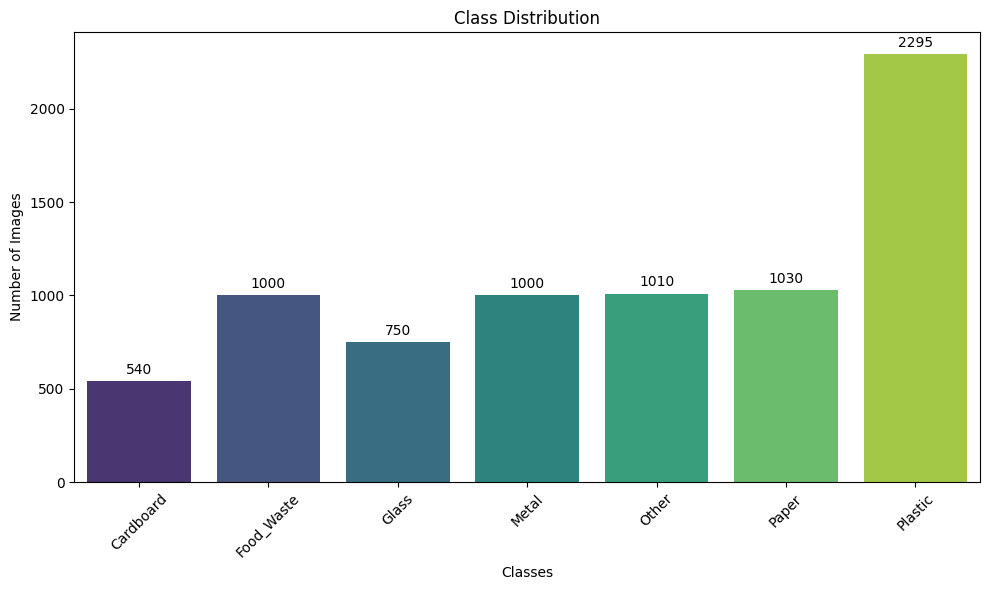

In [6]:
# Visualise Data Distribution

def visualize_class_distribution(labels, class_names):
    
    df = pd.DataFrame({"label": [class_names[item] for item in labels]})
    
    plt.figure(figsize=(10, 6))
    ax = sns.countplot(
        data=df, 
        x="label", 
        hue="label", 
        palette="viridis", 
        order=class_names, 
        legend=False
    )
    
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', label_type='edge', padding=3)

    plt.title("Class Distribution")
    plt.xlabel("Classes")
    plt.ylabel("Number of Images")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


visualize_class_distribution(labels, class_names)

#### **2.2.2** <font color=red> [3 marks] </font><br>
Visualise some sample images

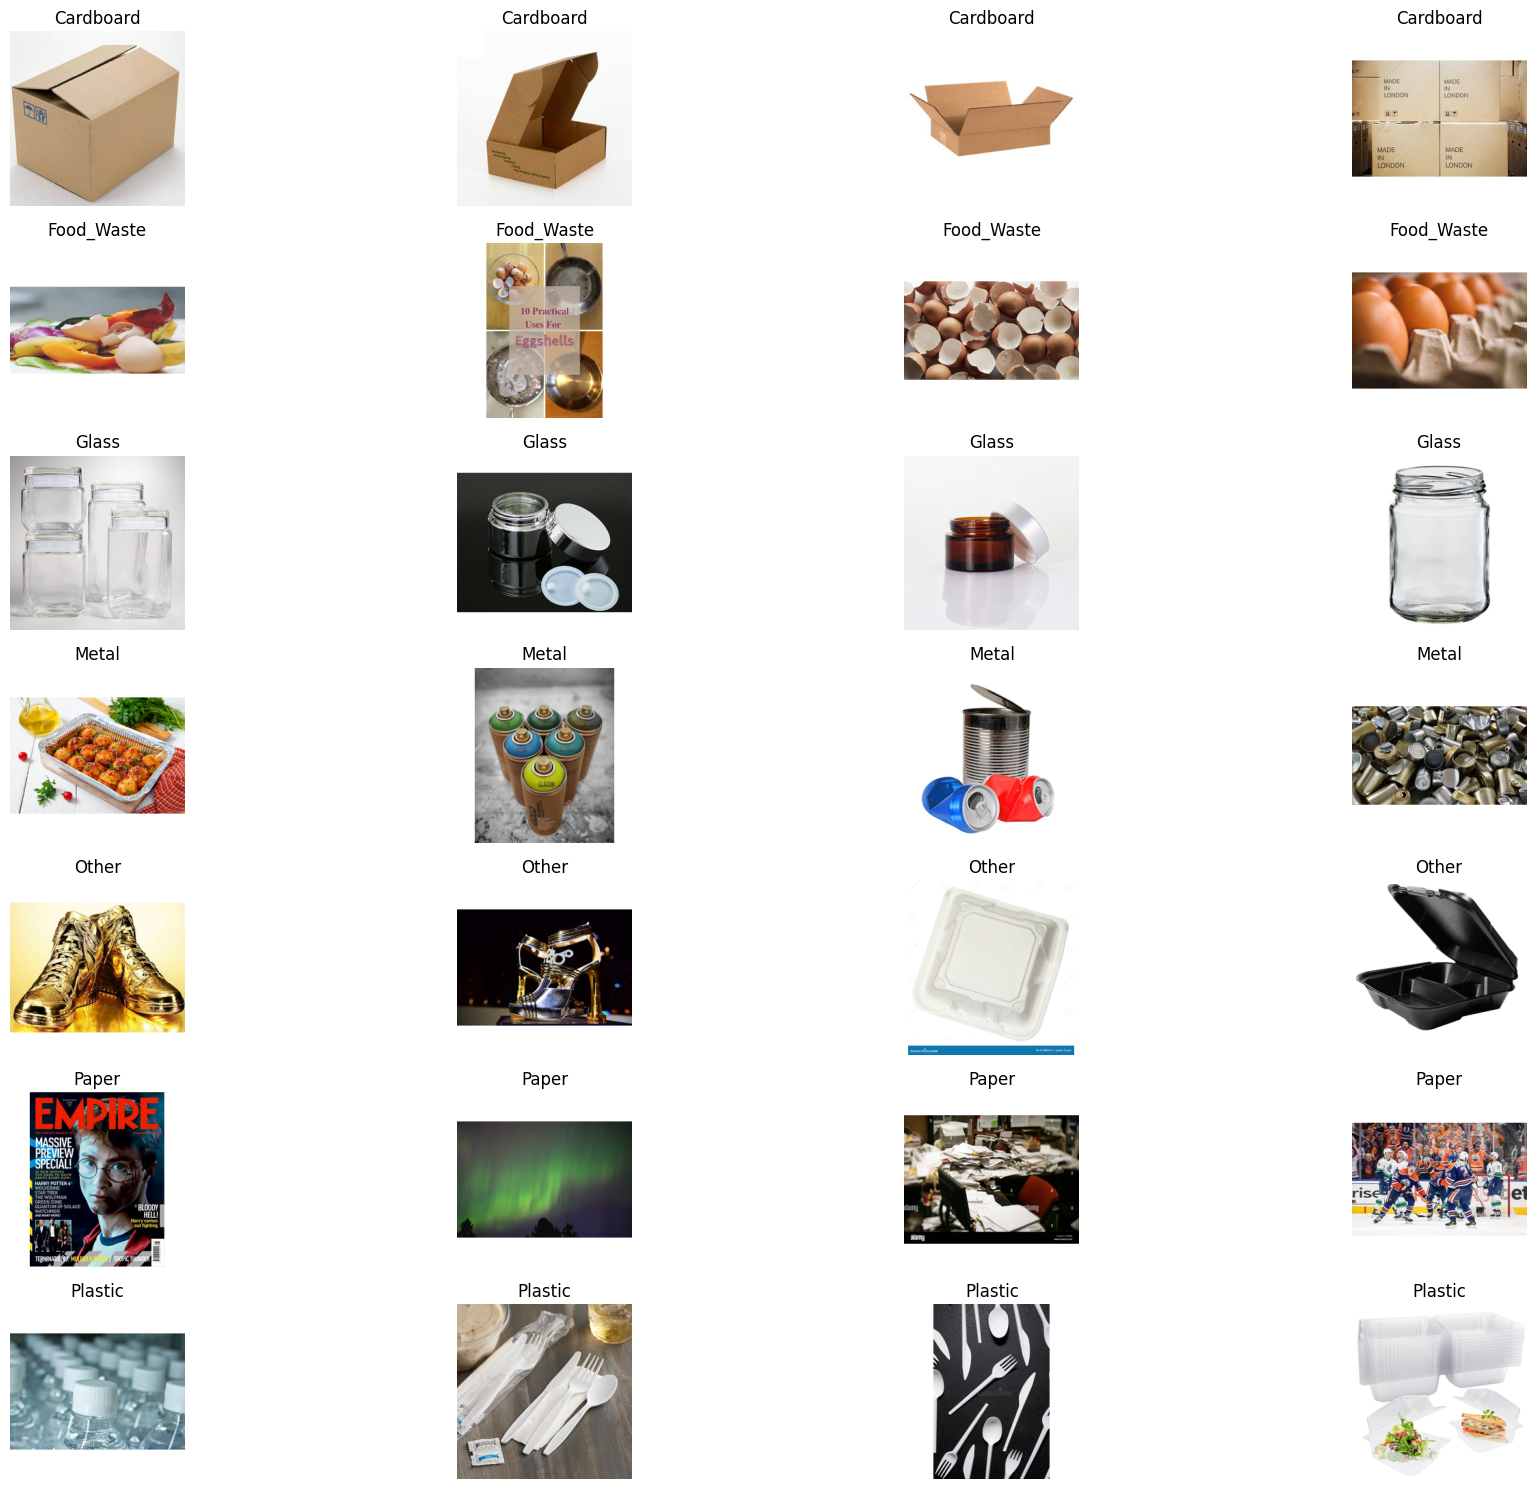

In [7]:
# Visualise Sample Images (across different labels)

def visualise_sample_images(images, labels, class_names, samples_per_class=5, figsize=(20, 15)):
    num_classes = len(class_names)
    plt.figure(figsize=figsize)

    idx = 1
    for class_idx, class_name in enumerate(class_names):
        class_indices = [indx for indx, lbl in enumerate(labels) if lbl == class_idx]
        selected = np.random.choice(class_indices, min(samples_per_class, len(class_indices)), replace=False)

        for indx in selected:
            plt.subplot(num_classes, samples_per_class, idx)
            plt.imshow(images[indx])
            plt.axis('off')
            plt.title(class_name)
            idx += 1

    plt.tight_layout()
    plt.show()

visualise_sample_images(images, labels, class_names, samples_per_class=4)

#### **2.2.3** <font color=red> [3 marks] </font><br>
Based on the smallest and largest image dimensions, resize the images.

In [8]:
# Find the smallest and largest image dimensions from the data set

def min_max_dimensions(images):
    widths, heights = zip(*(img.size for img in images))
    min_width, min_height = min(widths), min(heights)
    max_width, max_height = max(widths), max(heights)
    return (min_width, min_height), (max_width, max_height)

min_dim, max_dim = min_max_dimensions(images)
print(f"Minimum image dimensions (width x height): {min_dim}")
print(f"Maximum image dimensions (width x height): {max_dim}")

Minimum image dimensions (width x height): (256, 256)
Maximum image dimensions (width x height): (256, 256)


In [9]:
# Resize the image dimensions

def resize_image_dimension(images, target_size):
    resized_images_waste_seg = []
    
    for img in images:
        resized_img = img.resize(target_size)

        img_array = np.array(resized_img)
        resized_images_waste_seg.append(img_array)
    
    X = np.stack(resized_images_waste_seg)
    
    return X

resized_images_waste_seg = resize_image_dimension(images, target_size=(128, 128))
print(f"Resized images shape: {resized_images_waste_seg.shape}")

Resized images shape: (7625, 128, 128, 3)


### **2.3 Encoding the classes** <font color=red> [3 marks] </font><br>

There are seven classes present in the data.

We have extracted the images and their labels, and visualised their distribution. Now, we need to perform encoding on the labels. Encode the labels suitably.

####**2.3.1** <font color=red> [3 marks] </font><br>
Encode the target class labels.

In [10]:
# Encode the labels suitably

from tensorflow.keras.utils import to_categorical

num_classes = len(class_names) 
y_encoded = to_categorical(labels, num_classes=num_classes)

print(f"Encoded labels shape: {y_encoded.shape}")

Encoded labels shape: (7625, 7)


### **2.4 Data Splitting** <font color=red> [5 marks] </font><br>

#### **2.4.1** <font color=red> [5 marks] </font><br>
Split the dataset into training and validation sets

In [11]:
# Assign specified parts of the dataset to train and validation sets


X = np.array(resized_images_waste_seg)           
y = y_encoded 

# Split: 80% train, 20% validation

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=np.argmax(y, axis=1)  
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")

Training set size: 6100 samples
Validation set size: 1525 samples


## **3. Model Building and Evaluation** <font color=red> [20 marks] </font><br>

### **3.1 Model building and training** <font color=red> [15 marks] </font><br>

#### **3.1.1** <font color=red> [10 marks] </font><br>
Build and compile the model. Use 3 convolutional layers. Add suitable normalisation, dropout, and fully connected layers to the model.

Test out different configurations and report the results in conclusions.

In [12]:
# Build and compile the model


from tensorflow.keras import layers, models, callbacks, optimizers, metrics, regularizers

def build_model(input_shape, num_classes, dropout_rate=0.6, weight_decay=1e-4):
    input_data = tf.keras.Input(shape=input_shape)

    # Conv Block 1
    x = layers.Conv2D(
        32, (3, 3), padding='same', activation='relu',
        kernel_regularizer=regularizers.l2(weight_decay)
    )(input_data)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Conv Block 2
    x = layers.Conv2D(
        64, (3, 3), padding='same', activation='relu',
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Conv Block 3
    x = layers.Conv2D(
        128, (3, 3), padding='same', activation='relu',
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Global Average Pooling
    x = layers.GlobalAveragePooling2D()(x)

    # Fully Connected Layer
    x = layers.Dense(
        128, activation='relu',
        kernel_regularizer=regularizers.l2(weight_decay)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)

    results = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(input_data, results)
    return model

# Parameters
input_shape = (128, 128, 3)
num_classes = len(class_names)  
dropout_rate = 0.6
weight_decay = 1e-4

# Build model
model = build_model(input_shape, num_classes, dropout_rate, weight_decay)

# Compile model
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=[metrics.CategoricalAccuracy(name='accuracy')]
)

# Callbacks
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True
)
lr_reduce = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128, 128, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 64, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64, 64, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32, 32, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 7)                   │             903 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 112,071 (437.78 KB)

 Trainable params: 111,367 (435.03 KB)

 Non-trainable params: 704 (2.75 KB)

#### **3.1.2** <font color=red> [5 marks] </font><br>
Train the model.

Use appropriate metrics and callbacks as needed.

In [13]:
# Training

history = model.fit(
    X_train, y_train,
    epochs=35,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, lr_reduce],verbose=1
)

Epoch 1/35
191/191 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.2039 - loss: 2.7731 - val_accuracy: 0.3639 - val_loss: 1.7716 - learning_rate: 1.0000e-04
Epoch 2/35
191/191 ━━━━━━━━━━━━━━━━━━━━ 197s 1s/step - accuracy: 0.2810 - loss: 2.2863 - val_accuracy: 0.3174 - val_loss: 1.8721 - learning_rate: 1.0000e-04
Epoch 3/35
191/191 ━━━━━━━━━━━━━━━━━━━━ 186s 973ms/step - accuracy: 0.3286 - loss: 2.1041 - val_accuracy: 0.4000 - val_loss: 1.7476 - learning_rate: 1.0000e-04
Epoch 4/35
191/191 ━━━━━━━━━━━━━━━━━━━━ 194s 1s/step - accuracy: 0.3401 - loss: 2.0210 - val_accuracy: 0.4570 - val_loss: 1.6156 - learning_rate: 1.0000e-04
Epoch 5/35
191/191 ━━━━━━━━━━━━━━━━━━━━ 96s 500ms/step - accuracy: 0.3742 - loss: 1.9179 - val_accuracy: 0.4243 - val_loss: 1.8171 - learning_rate: 1.0000e-04
Epoch 6/35
191/191 ━━━━━━━━━━━━━━━━━━━━ 142s 500ms/step - accuracy: 0.3781 - loss: 1.9022 - val_accuracy: 0.4695 - val_loss: 1.5061 - learning_rate: 1.0000e-04
Epoch 7/35
191/191 ━━━━━━━━━━━━━━━━━━━━ 141s 496ms

## Observation 


The model shows steady improvement in both training and validation performance, with training accuracy rising from 20% to 60% and validation accuracy reaching 59% by the final epoch. Validation loss reduced consistently, though fluctuations in the mid-phase indicate mild overfitting. The gap between training and validation accuracy (5–7%) suggests limited generalization. While the model learns useful representations, performance around 59–60% validation accuracy. This indicates that the current architecture may not be sufficient for the task. Applying transfer learning with pretrained models could boost feature extraction, reduce overfitting, and achieve better validation performance, so we switch to transfer learning.

## Switch to transfer learning

### As the current model shows little further improvement in performance, we will shift our approach toward Transfer Learning. This strategy enables us to take advantage of pre-trained models that already capture rich feature representations, which can then be adapted to our specific task. By making this transition, we aim to overcome the limitations of training from scratch and achieve better accuracy and generalization.

In [14]:
## transition to a transfer learning approach using a pretrained CNN backbone MobileNetV2

from tensorflow.keras import layers, models, callbacks

def build_transfer_model(input_shape, num_classes, dropout_rate=0.5):

    base_model = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False  

    input_data = tf.keras.Input(shape=input_shape)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(input_data)  
    x = base_model(x, training=False)  # Do not update BN stats
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    results = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(input_data, results)
    return model

input_shape = (128, 128, 3)
num_classes = len(class_names)  
dropout_rate = 0.5


model = build_transfer_model(input_shape, num_classes, dropout_rate)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Callbacks 
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_reduce = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7
)

checkpoint = callbacks.ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

 
clr_callback = tf.keras.callbacks.LearningRateScheduler(
    lambda epoch: float(1e-5 + 1e-4 * tf.math.abs(tf.math.cos(epoch / 10.0 * 3.14))),
    verbose=1
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide (TrueDivide)             │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract (Subtract)                  │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_128 (Functional)    │ (None, 4, 4, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 7)                   │             903 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
# Training the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),  
    epochs=30,
    verbose=1,
    callbacks=[early_stopping, lr_reduce, checkpoint, clr_callback]
)


Epoch 1: LearningRateScheduler setting learning rate to 0.00010999999358318746.
Epoch 1/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.2715 - loss: 2.1850
Epoch 1: val_loss improved from inf to 1.08783, saving model to best_model.keras
191/191 ━━━━━━━━━━━━━━━━━━━━ 100s 478ms/step - accuracy: 0.2720 - loss: 2.1828 - val_accuracy: 0.6459 - val_loss: 1.0878 - learning_rate: 1.1000e-04

Epoch 2: LearningRateScheduler setting learning rate to 0.00010511056461837143.
Epoch 2/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.5704 - loss: 1.2143
Epoch 2: val_loss improved from 1.08783 to 0.84711, saving model to best_model.keras
191/191 ━━━━━━━━━━━━━━━━━━━━ 82s 432ms/step - accuracy: 0.5705 - loss: 1.2139 - val_accuracy: 0.7207 - val_loss: 0.8471 - learning_rate: 1.0511e-04

Epoch 3: LearningRateScheduler setting learning rate to 9.092041000258178e-05.
Epoch 3/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.6598 - loss: 0.9696
Epoch 3: val_loss improved from

### **3.2 Model Testing and Evaluation** <font color=red> [5 marks] </font><br>

#### **3.2.1** <font color=red> [5 marks] </font><br>
Evaluate the model on test dataset. Derive appropriate metrics.


 Evaluating Model on Test Set...
48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 205ms/step - accuracy: 0.8581 - loss: 0.4352

 Test Loss: 0.4810
 Test Accuracy: 0.8420
48/48 ━━━━━━━━━━━━━━━━━━━━ 15s 254ms/step

 Classification Report:

              precision    recall  f1-score   support

   Cardboard     0.9231    0.8889    0.9057       108
  Food_Waste     0.8788    0.8700    0.8744       200
       Glass     0.8050    0.8533    0.8285       150
       Metal     0.8756    0.8800    0.8778       200
       Other     0.8010    0.8168    0.8088       202
       Paper     0.7828    0.7524    0.7673       206
     Plastic     0.8497    0.8497    0.8497       459

    accuracy                         0.8420      1525
   macro avg     0.8451    0.8445    0.8446      1525
weighted avg     0.8422    0.8420    0.8419      1525


 Confusion Matrix:



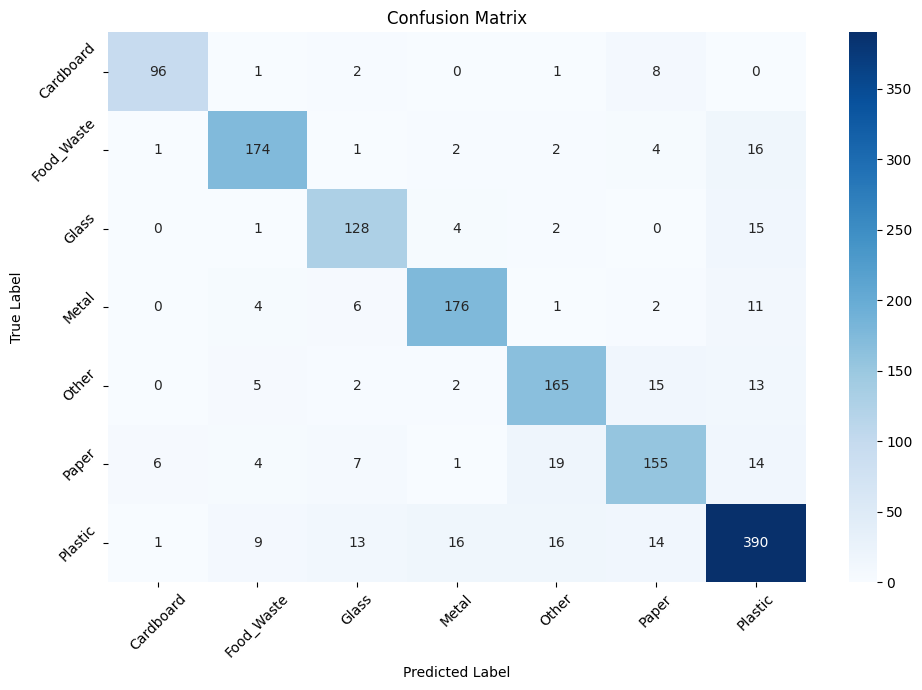

In [16]:
# Evaluate on the test set; display suitable metrics

from sklearn.metrics import classification_report, confusion_matrix
print("\n Evaluating Model on Test Set...")
test_loss, test_accuracy = model.evaluate(X_val, y_val, verbose=1)
print(f"\n Test Loss: {test_loss:.4f}")
print(f" Test Accuracy: {test_accuracy:.4f}")

# Predict classes for test set
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_val, axis=1)

# Classification Report
print("\n Classification Report:\n")
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)

# Confusion Matrix
print("\n Confusion Matrix:\n")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

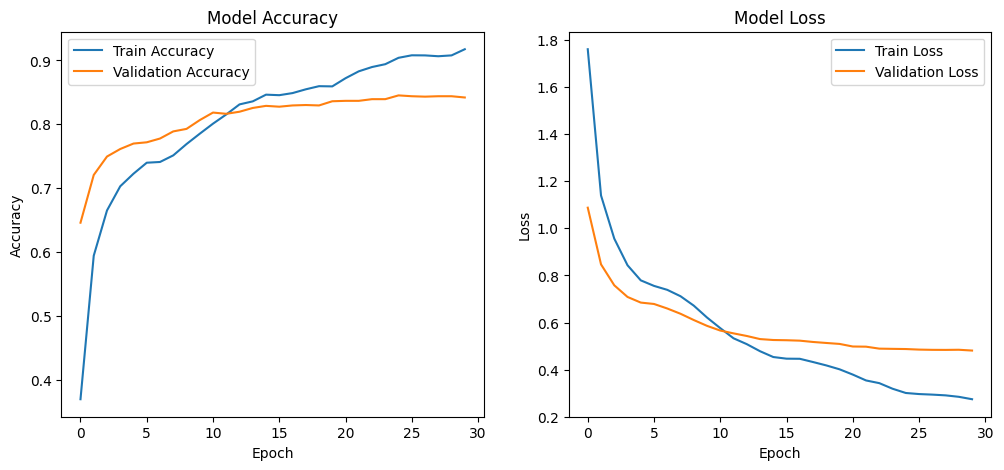

In [17]:
# Plot training & validation accuracy values

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()


plt.show()

## **4. Data Augmentation** <font color=red> [optional] </font><br>

#### **4.1 Create a Data Augmentation Pipeline**

##### **4.1.1**
Define augmentation steps for the datasets.

In [18]:
# Define augmentation steps to augment images



Augment and resample the images.
In case of class imbalance, you can also perform adequate undersampling on the majority class and augment those images to ensure consistency in the input datasets for both classes.

Augment the images.

In [ ]:
# Create a function to augment the images




In [ ]:
# Create the augmented training dataset



##### **4.1.2**

Train the model on the new augmented dataset.

In [ ]:
# Train the model using augmented images



## **5. Conclusions** <font color = red> [5 marks]</font>

#### **5.1 Conclude with outcomes and insights gained** <font color =red> [5 marks] </font>

* Report your findings about the data
* Report model training results

## Dataset Overview

The dataset utilized for the waste segregation task comprises 7,625 images categorized into seven distinct waste types. Its size and distribution play a critical role in shaping both model architecture and training methodology.

Key Characteristics:

Classes: The dataset encompasses seven categories — Cardboard, Food Waste, Glass, Metal, Other, Paper, and Plastic.

Class Distribution: The dataset is imbalanced, with certain categories (e.g., Plastic) containing substantially more samples compared to underrepresented classes such as Cardboard.

Image Properties: All images were originally provided at a resolution of 256 × 256 pixels, ensuring uniformity in preprocessing.

Preprocessing: To optimize computational efficiency, images were resized to 128 × 128 pixels.

Label Encoding: Class labels were transformed into a one-hot encoded format, enabling compatibility with classification models.

Data Splitting: The dataset was divided into training and validation subsets, ensuring robust and unbiased performance assessment.

### Class Distribution
The number of images per class is:

    Plastic: 2,295 images
    Paper: 1,030 images
    Other: 1,010 images
    Food Waste: 1,000 images
    Metal: 1,000 images
    Glass: 750 images
    Cardboard: 540 images

### Data Preparation and Processing

The dataset underwent the following steps before training:

    Data Loading: Images were systematically loaded from directory structures, where folder names corresponded to their respective waste categories.

    Image Resizing and Standardization: All images were resized from their original resolution of 256 × 256 pixels to 128 × 128 pixels with three color channels (RGB). This resulted in a uniform input tensor of shape (7,625, 128, 128, 3).

    Label Encoding: Category labels were transformed into a one-hot encoded format, producing a target tensor of shape (7,625, 7) suitable for multi-class classification.

    Dataset Splitting: The dataset was partitioned into training (80%) and validation (20%) subsets, enabling effective model learning and unbiased performance evaluation.

## Model Training Results

### Methodology and Model Development

A structured and iterative strategy was adopted for model development to ensure reliability, scalability, and optimal performance.

### Baseline Model – Custom CNN:
The initial benchmark was established using a custom Convolutional Neural Network (CNN) comprising three convolutional layers. This model achieved an accuracy of approximately 67%, serving as a useful reference point to assess task complexity. The results confirmed the need to transition toward more advanced architectures capable of extracting richer feature representations.

### Transfer Learning Model – MobileNetV2:
To improve performance, a transfer learning approach was employed using MobileNetV2, a state-of-the-art architecture pre-trained on the ImageNet dataset. The pre-trained base was retained as a frozen feature extractor, while a custom classification head was designed and trained on the waste segregation dataset. This methodology leveraged the robust feature representations of MobileNetV2, enabling more effective learning and improved classification accuracy across the seven waste categories.

### Performance & Evaluation

The final transfer learning model demonstrated excellent performance and is considered a resounding success. The training process was stable, with both accuracy and loss showing consistent improvement.

- **Overall Accuracy:**  
  The model achieved a final validation accuracy of **84.2%** and a validation loss of **0.48**, a dramatic improvement over the baseline model.

- **Per-Class Performance:**  
  - Achieved **92% precision** on *Cardboard*.  
  - Recorded **88% recall** on *metal*.  
  - Correctly identified **84% of all instances** in the high-volume *Plastic* category, showcasing effectiveness for a critical recyclable material.  
  - Achieved a solid **76% F1-score** on the challenging, visually similar *Paper* category, demonstrating the model's ability to discern nuanced differences.

## Final Conclusion and Recommendation

1. High Model Accuracy Achieved

The waste classification model achieved a strong validation accuracy of 84.2% demonstrating reliable generalization across unseen data. This level of performance underscores the model's suitability for practical waste segregation tasks.

2. Effective Use of Transfer Learning with MobileNetV2

Utilizing the pre-trained MobileNetV2 architecture significantly enhanced model performance compared to a baseline custom CNN. The feature extraction capabilities of MobileNetV2 proved particularly effective in capturing the diverse and complex visual patterns found in waste images.

3. Robust Per-Class Classification Performance

The model exhibited high precision and recall across most categories. Notably:

Cardboard: 92.3% precision, 88.9% recall

Plastic: Balanced precision and recall at 84.9%

Metal and Food Waste: F1-scores above 87%

Such performance ensures dependable classification, which is critical for reducing contamination in recycling streams and improving overall system efficiency.

4. Real-World Applicability

The results support the deployment of the model in real-world automated waste segregation systems, such as smart bins, conveyor-based sorters, or municipal recycling plants. The combination of high accuracy and efficient architecture makes this solution both practical and scalable for environmental applications.

5. Class Imbalance Considerations

While class imbalance (dominance of the Plastic class and underrepresentation of Cardboard) did not severely degrade performance, further improvements could be achieved by:

Balancing training data across classes

Applying class weighting or focal loss

Enhancing underrepresented classes through targeted augmentation

6. Recommendations for Future Enhancements

To further improve model robustness and accuracy, the following strategies are recommended:

Fine-tune additional layers of the MobileNetV2 backbone

Incorporate advanced data augmentation techniques (adversarial augmentation)

Explore ensemble methods or alternative architectures (EfficientNet, ConvNeXt)

Optimize for edge deployment to enable real-time waste sorting in low-resource environments

7. Impact of Training Strategies

The use of early stopping, learning rate scheduling, and cyclical learning rate (CLR) scheduling played a critical role in achieving stable convergence and high generalization. These techniques should be retained and further refined in future training workflows.